In [1]:
import torch 
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import *
import torch.distributions.normal as normal

import numpy as np
import random
import matplotlib.pyplot as plt
from collections import OrderedDict
from scipy import signal
import pytorch_ssim

from Software.basemodel import *
from Software.data_handler import *
from Software.optimizer import *
from Software.fit import *
import Software.cbs
#from Software.unet import Unet_sigmoid
#import Software.unet_ein as ue

In [2]:
import Software.custom_loss

In [3]:
def save(path,results,names = ['normal','attack','disable','end','test']):
    for i in range(len(results)):
        np.save(path+names[i]+'.npy',results[i])

# Data

In [4]:
trn_ , val_ = split('../dataset/fuz attack/lka_can/normal/bin/',prc = 0.2, dataset_pct=  1, dim =(112,112), word_type=torch.float)
atk , _ = split('../dataset/fuz attack/lka_can/attack/bin/',prc = 0 , dataset_pct=  1, dim = (112,112), word_type=torch.float)

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/fuz attack/lka_can/normal/bin/'

In [8]:
trn_.data= trn_.data[80*220:]

In [9]:
atk.data = trn_.data + val_.data+ atk.data

In [10]:
bs = 8
seq_len = 10
overlap=0

In [11]:
trn_dl = Sequence_dl( trn_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
v4_val_dl = Sequence_dl( val_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])

In [12]:
v4_anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])

In [13]:
dl =CombineDataLoader(trn_dl,v4_val_dl)

#### Custom Loss

In [17]:
loss = custom_loss.mse()

### Helping Methods

In [18]:
import noise

In [22]:
#load Data
vis = np.load('../dataset/fuz attack/generated_ds/amr/array.npy')

# Model : Predict LKA

In [24]:
### Load Model

In [25]:
m =  unet_seq(bs,seq_len).cuda()

In [38]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [39]:
m.gen_vis = np.load('../dataset/fuz attack/generated_ds/amr/array.npy')
m.test = False
m.max_count = len(trn_dl)+len(v4_val_dl)

In [40]:
#cbs.load_all('publication/predict lka with dec vis/mse normalized/',model=m,opt=opt,learn=learn)
#cbs.load_all('publication/recon_hist_dec_vis/mse/',model=m,opt=opt,learn=learn)

In [41]:
m.test = True
m.max_count =  len(v4_anml_dl)
m.lka = torch.zeros(1).cuda()
m.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
l1 = range(250,3500,100)
l = [[],[400],[250,400,1000,2400],[1000,1500],[1500],[2400],l1]
m.art_lka = l[0]#range(0,3500,50)

In [42]:
v4_anml_item.evaluate(model = m , crit = loss)

  0%|          | 0/3577 [00:00<?, ?it/s]

testing...


/home/amr/anaconda3/envs/fast2/lib/python3.6/site-packages/ipykernel_launcher.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


In [57]:
len(v4_anml_dl)

3577

In [42]:
op_list = []
lka_list = []
vis_list = []
for i in range(len(noise_type)):
    m =  unet_seq(bs,seq_len).cuda()
    m.noise = Noise(noise_type[i])
    cbs.load_all('publication/predict lka with dec vis/mse normalized/',model=m,opt=opt,learn=learn)
    m.test = True
    m.max_count = len(v4_anml_dl)
    m.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
    m.art_lka = l[-1]
    
    v4_anml_item.evaluate(model = m , crit = loss)
    op_list.append(torch.tensor(v4_anml_item.test_loss))
   
    lka_list.append([i[0][0]for i in m.flag_list])
    vis_list.append([i[-1]for i in m.flag_list])
    

/home/amr/.local/lib/python3.6/site-packages/ipykernel_launcher.py:93: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  0%|          | 9/3577 [00:00<00:41, 85.29it/s]

testing...


  8%|▊         | 278/3577 [00:02<00:24, 137.44it/s]

fake


 11%|█         | 379/3577 [00:02<00:22, 139.23it/s]

...

 94%|█████████▍| 3374/3577 [00:26<00:01, 132.89it/s]

fake


 97%|█████████▋| 3469/3577 [00:26<00:00, 131.90it/s]

fake


100%|█████████▉| 3564/3577 [00:27<00:00, 128.76it/s]

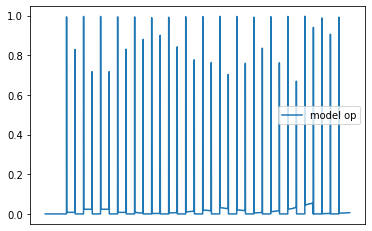

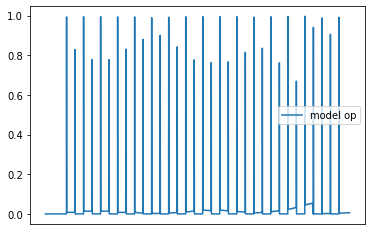

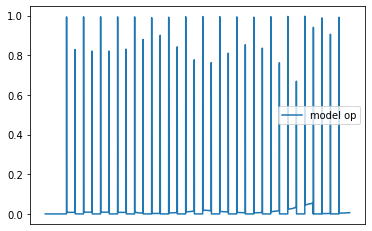

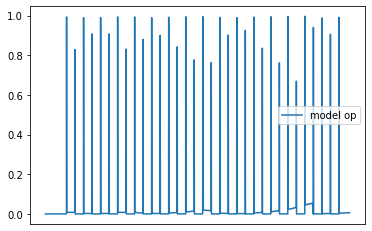

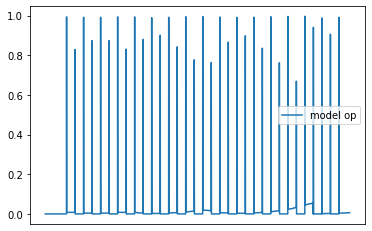

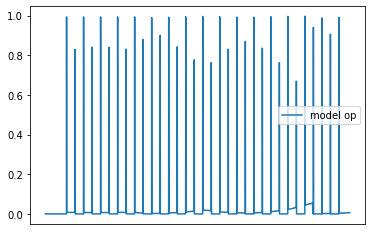

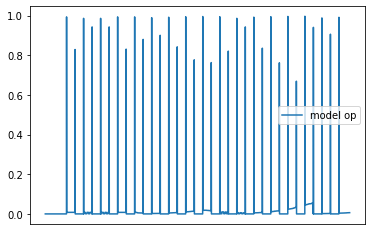

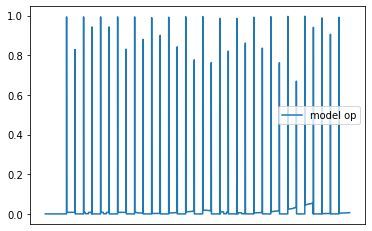

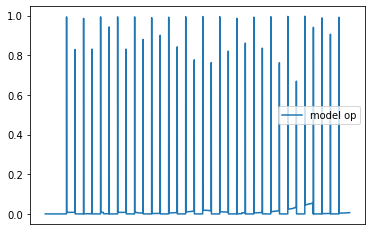

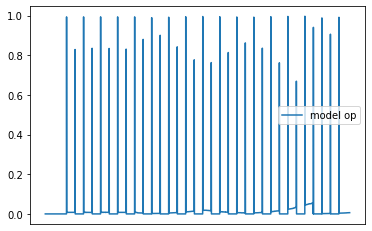

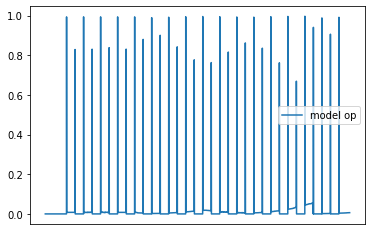

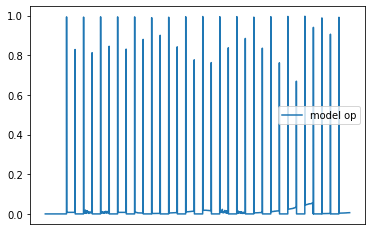

In [45]:
d = 7
label = ['a','b','c','d','e','f','g','h','i']
for i in range(1,len(op_list)):
    fig,ax = plt.subplots()
    plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
    
    #plt.ylabel('Loss function value',fontsize=18)
    #plt.xlabel(f'({label[i-1]})         time',fontsize=18)
    #plt.yticks(ticks=[])
    ax.plot(range(len(op_list[i])),list(op_list[i]),label='model op')
    #ax.plot(range(len(vis_list[i][1:])),vis_list[i][1:],label='RLD')
    #ax.plot(range(len(lka_list[i])),lka_list[i],label='lka')
    ax.legend()
    path = 'Models/publication/predict lka with dec vis/mse normalized/'
    #fig.savefig(f'{path}{d+i}/i.png' , format = 'png' , dpi=300,bbox_inches = 'tight',pad_inches=0.1)
    #np.save(f'{path}/{d+i}/attack.npy',op_list[i])
    #np.save(f'{path}/{d+i}/vis.npy',vis_list[i])
    #np.save(f'{path}/{d+i}/lka.npy',lka_list[i])